In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('amazon_sales_dataset.csv')
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [3]:
df['rating'].corr(df['discount_percent'], method='spearman')

np.float64(0.0031730363882495716)

In [4]:
df['product_category'].unique()

array(['Books', 'Fashion', 'Sports', 'Beauty', 'Electronics',
       'Home & Kitchen'], dtype=object)

In [5]:
books = df[df['product_category'] == 'Books']
fashion = df[df['product_category'] == 'Fashion']
beauty = df[df['product_category'] == 'Sports']
sports = df[df['product_category'] == 'Beauty']
electr = df[df['product_category'] == 'Electronics']

In [6]:
books_rtpd = books[books['rating'] >= 4.6]
fashion_rtpd = fashion[fashion['rating'] >= 4.6]
beauty_rtpd = beauty[beauty['rating'] >= 4.6]
sports = sports[sports['rating'] >= 4.6]
electr = electr[electr['rating'] >= 4.6]

In [7]:
books_top = (
    books_rtpd
    .groupby('customer_region')
    .size()
    .sort_values(ascending = False)
)
fashion_top = (
    fashion_rtpd
    .groupby('customer_region')
    .size()
    .sort_values(ascending = False)
)
beauty_top = (
    beauty_rtpd
    .groupby('customer_region')
    .size()
    .sort_values(ascending = False)
)
sports_top = (
   sports
    .groupby('customer_region')
    .size()
    .sort_values(ascending = False)
)
electr_top = (
   electr
    .groupby('customer_region')
    .size()
    .sort_values(ascending = False)
)

In [8]:
top_prod = pd.DataFrame({
    'Books': books_top,
    'Beauty' : fashion_top,
    'Fashion' : beauty_top,
    'Sports' : sports_top,
    'Electr' : electr_top
})
top_prod

,Books,Beauty,Fashion,Sports,Electr
customer_region,,,,,
Asia,243,200,221,234,203
Europe,222,227,244,220,250
Middle East,263,248,220,220,222
North America,223,230,231,237,250


<Figure size 1000x500 with 0 Axes>

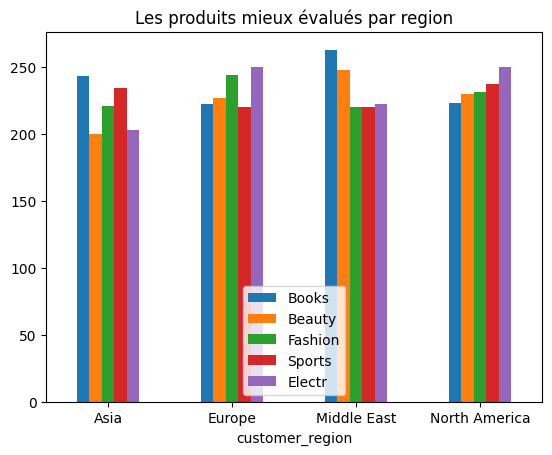

In [9]:
plt.figure(figsize = (10,5))
top_prod.plot(kind = 'bar')
plt.title('Les produits mieux évalués par region')
plt.xticks(rotation = 0)
plt.show()